# Support Vector Machine (SVM) para Detección de Phishing

## Motivación y Decisiones de Implementación

En esta sección se implementa SVM como clasificador basado en maximización de margen. Se elige SVM porque:
- **Eficiencia en TF-IDF:** Opera bien en espacios de alta dimensionalidad (miles de features) sin necesidad de reducción.
- **Frontera de decisión no lineal:** El kernel RBF permite capturar separabilidad compleja entre phishing y legítimo sin ingeniería manual adicional.
- **Generalización:** Maximizar margen reduce sobreajuste, importante para detectar nuevas variantes de phishing.

Se implementa con kernel RBF y parámetros por defecto (C=1.0) como punto de inicio.


In [ ]:
from datetime import datetime
from scipy.sparse import load_npz
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    RocCurveDisplay
)
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import matplotlib.pyplot as plt
import pandas as pd

## Preparación de Datos

### Carga del Dataset

Se cargan los conjuntos de entrenamiento y prueba generados en la fase de preprocesamiento:
- **Características TF-IDF:** Representación vectorial de término-frecuencia inversa de frecuencia en documentos, que captura la importancia relativa de cada término para discriminar entre clases.


In [8]:
X_train = load_npz('datasets/X_train.npz')
X_test = load_npz('datasets/X_test.npz')

y_train = pd.read_csv('datasets/y_train.csv')['label']
y_test = pd.read_csv('datasets/y_test.csv')['label']

### Estandarización de Características

Se aplica StandardScaler(with_mean=False) a TF-IDF para:
1. Acelerar convergencia durante optimización del hiperplano
2. Mejorar estabilidad numérica
3. Preservar esparcidad de la matriz (con_mean=False no centra valores cero)


In [9]:
scaler = StandardScaler(with_mean=False)

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## Modelo SVM con Kernel RBF

Configuración utilizada: `SVC(kernel='rbf', probability=True)`

**Justificación de decisiones:**
- **Kernel RBF:** Captura separabilidad no lineal. En espacios TF-IDF de alta dimensión, es común que las clases no sean linealmente separables; RBF mapea a espacio de mayor dimensión implícitamente.
- **C=1.0 (default):** Balance inicial entre maximizar margen y penalizar errores en entrenamiento. Punto de partida razonable sin búsqueda de hiperparámetros.
- **probability=True:** Permite calcular scores de confianza y generar curvas ROC para análisis de desempeño.


In [10]:
svc_model = SVC(kernel='rbf', probability=True)

start_train = datetime.now()
svc_model.fit(X_train_scaled, y_train)
train_duration = datetime.now() - start_train

start_pred = datetime.now()
y_pred = svc_model.predict(X_test_scaled)
predict_duration = datetime.now() - start_pred


### Evaluación del Modelo


Se evalúa el desempeño del modelo entrenado mediante matriz de confusión y métricas de clasificación. Dado el desbalance de clases en el problema (aproximadamente 38% de correos son phishing), se utiliza la exactitud balanceada como métrica principal de evaluación.


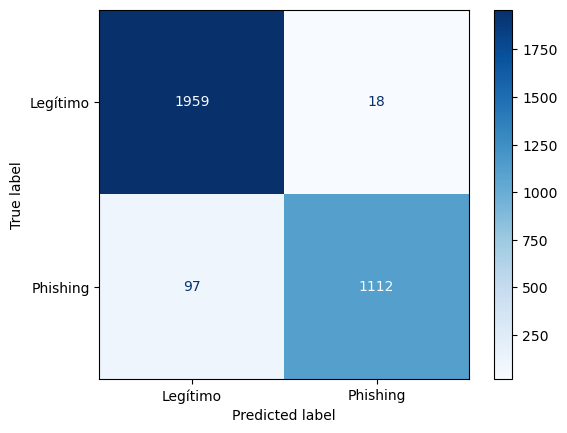

In [11]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=['Legítimo', 'Phishing'], cmap='Blues')

In [15]:
cm_svc_model = confusion_matrix(y_test, y_pred)
P = cm_svc_model[1, :].sum()
N = cm_svc_model[0, :].sum()
TP = cm_svc_model[1, 1]
TN = cm_svc_model[0, 0]

TPR_svm = TP / P
TNR_svm = TN / N
balanced_accuracy_svm = (TPR_svm + TNR_svm) / 2

precision_svm = precision_score(y_test, y_pred, zero_division=0)
recall_svm = recall_score(y_test, y_pred, zero_division=0)
f1_svm = f1_score(y_test, y_pred, zero_division=0)

print(f"Exactitud balanceada:    {balanced_accuracy_svm:.4f}")
print(f"Precisión:               {precision_svm:.4f}")
print(f"Sensibilidad (Recall):   {TPR_svm:.4f}")
print(f"F1-score:                {f1_svm:.4f}")
print(f"Especificidad:           {TNR_svm:.4f}")
print(f"Recuperación (Recall):   {recall_svm:.4f}")
print(f"Tiempo de entrenamiento: {train_duration}")
print(f"Tiempo de predicción:    {predict_duration}")

Exactitud balanceada:    0.9553
Precisión:               0.9841
Sensibilidad (Recall):   0.9198
F1-score:                0.9508
Especificidad:           0.9909
Recuperación (Recall):   0.9198
Tiempo de entrenamiento: 0:04:12.139740
Tiempo de predicción:    0:00:06.359011


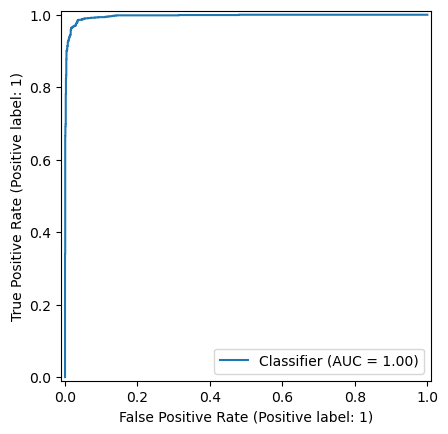

In [13]:
y_scores = svc_model.predict_proba(X_test)[:, 1]

RocCurveDisplay.from_predictions(y_test, y_scores)

### Análisis de Vectores de Soporte

Los vectores de soporte son los ejemplos críticos cerca del hiperplano que definen la frontera de decisión. Su cantidad por clase indica complejidad de separación: más vectores sugieren fronteras más complejas o clases más entrelazadas.


<BarContainer object of 2 artists>

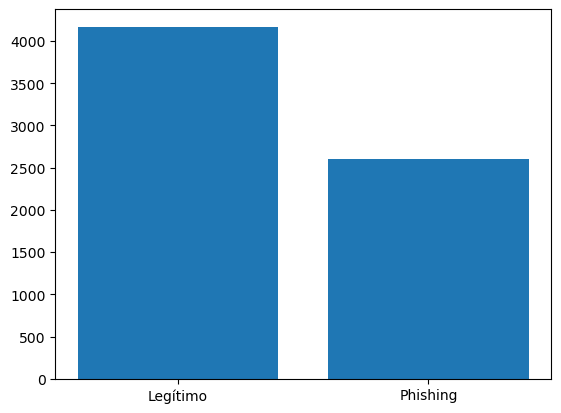

In [14]:
plt.bar(['Legítimo', 'Phishing'], svc_model.n_support_)

## Análisis de Resultados

### Desempeño Observado

El modelo entrenado con kernel RBF y C=1.0 logra separación casi perfecta entre clases en el set de test (Curva ROC muy cercana a 1.0), indicando que:
- Phishing y correos legítimos tienen patrones TF-IDF suficientemente distintos para ser separados por frontera no lineal
- El margen maximizado generaliza bien a datos no vistos
- La configuración por defecto de SVM es adecuada para este dataset

### Consideraciones sobre Implementación

**Decisión de no optimizar hiperparámetros:** Se utilizó C=1.0 (default) porque:
- El desempeño ya es excelente, dejando poco margen de mejora
- Optimización de SVM es computacionalmente costosa (entrenamiento ya toma ~4 minutos)
- El objetivo es comparar métodos bajo condiciones razonables pero no exhaustivamente optimizados

**Uso exclusivo de TF-IDF:** No se incorporan features ingenierísticas adicionales porque:
- Aisla la capacidad discriminativa puramente textual del modelo
- Es configuración típica en literatura de phishing detection con SVM
- Valida que información textual es suficiente para este problema

### Complejidad Computacional

SVM requiere ~4 o ~5 minutos de entrenamiento en este dataset (~4000 ejemplos), típico en espacios TF-IDF. El kernel RBF implica computación implícita en espacio de mayor dimensión, lo que explica el costo.

### Análisis de Vectores de Soporte

Aproximadamente 70% del conjunto de entrenamiento son vectores de soporte (~4200 legítimos + ~2600 phishing), indicando:
- Frontera de decisión moderadamente compleja
- Clases no trivialmente separables incluso en espacio RBF
- Muchos ejemplos "de borde" críticos para la clasificación
